# Megacap-Concentration -- is 'just buy the biggest' genius or recency bias?
### Top-7/10 S&P 500 names vs the equal-weight index, 2008-2025

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Recency_bias%3F: Confirmed](https://img.shields.io/badge/Recency_bias%3F-Confirmed-8b949e?style=flat-square)

The Magnificent Seven -- Apple, Microsoft, Nvidia, Google, Amazon, Meta, Tesla -- dominated the 2020s so completely that a cottage industry of 'just buy the biggest' strategies emerged. The thesis is seductive: great companies *stay* great, their moats compound, and the index's cap-weight already tilts toward them -- so why not go all the way? This notebook asks the uncomfortable question: **is this a genuine edge, or are we just describing the last five years?**

> This is the plain-language layer. Want the t-stats, decade splits, and multiple-comparisons reckoning? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from megacap_concentration import data, strategy as st

CACHE_DIR = os.path.abspath("../_cache")
REPO_CACHE = os.path.abspath("../../../_cache")

def _have_cache():
    return (os.path.exists(os.path.join(CACHE_DIR, "megacap_annual_mcap.parquet")) and
            os.path.exists(os.path.join(CACHE_DIR, "megacap_annual_returns.parquet")))

HAVE_REAL = _have_cache()

def load_enriched(top_n=10):
    """Load real annual panel enriched with SPY, exclude partial 2026."""
    import numpy as np
    panel, meta = data.load_real(top_n=top_n, fetch=False, cache_dir=CACHE_DIR)
    panel = panel[panel["year"] < 2026].copy()
    annual = st.annual_portfolio_returns(panel, top_n=top_n, col="ret_annual")
    spy = st.spy_annual_returns(cache_dir=REPO_CACHE)
    return st.with_spy_benchmark(annual, spy), meta

print("real cache present:", HAVE_REAL)

# Frozen headline numbers mirroring docs/results.md (as-of 2026-06-15)
R = dict(
    n_years=18, n_tickers=412, n_tickers_total=412,
    topn10_mean=15.0, ew_mean=16.6, excess10_mean=-1.6, excess10_t=-0.31,
    topn10_sharpe=0.57,
    topn7_mean=13.7, excess7_mean=-2.9, excess7_t=-0.58,
    pre2015_topn=2.4,  pre2015_ew=16.5, pre2015_excess=-14.0, pre2015_t=-10.27,
    mid_topn=16.6,     mid_ew=16.3,     mid_excess=0.3,        mid_t=0.11,
    post2020_topn=28.3, post2020_ew=17.0, post2020_excess=11.3, post2020_t=1.30,
    topn10_vs_spy_mean=2.4, topn10_vs_spy_t=0.58,
    fingerprint="b6555c5c4c43",
)


real cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does top-10 beat equal-weight over the full 2008-2025 sample? | **No.** It *lags* by **1.6 ppt/year** on average (t=-0.31). |
| Did it ever work? | **Yes -- recently.** Post-2020 the top-10 won by **+11 ppt/year**, the Mag-7 era. |
| What happened before? | **The opposite.** Pre-2015 the top-10 lagged by **14 ppt/year** (t=-10.27) -- megacaps lost. |
| Is the recent win statistically solid? | **No.** 6 years of data, t=+1.30. Not enough to overcome the long history of underperformance. |
| Could you build a fund around it? | **No.** The universe is survivorship-biased, turnover costs are real, and the full-sample signal is negative. |

> **One sentence:** concentrating in the biggest S&P 500 names looks like genius because of the Magnificent-Seven era -- but over the full available history the top-10 *lagged* the average stock by 1.6 ppt/year, and before 2015 it lost by 14 ppt. That is the definition of recency bias.

## 1 -- The claim

> *'The biggest companies in the S&P 500 get big for a reason. Their competitive moats, brand power, and scale advantages mean they keep outperforming. Just buy the top 7 (or 10) by market cap and hold them for a year. It's a simpler, better strategy than the equal-weight index or the cap-weighted SPY.'*

The modern version of this claim rode the 2020s wave: Apple crossed \$3 trillion, Nvidia surged 10x in two years, Microsoft dominated cloud and AI. Every finance influencer started recommending 'the Magnificent Seven.' The question is whether the data supports this *as a general claim*, or whether it is a narrative retrofitted to one unusual half-decade.

## 2 -- So what?

The stakes are real. If it's true:
- Equal-weight ETFs like RSP underperform -- their biggest drawback is they dilute the winners.
- Passive investors in SPY leave alpha on the table vs. a simple 7-name portfolio.
- The academic 'size premium' (small beats large) is dead.

If it's false (or recency bias):
- Millions of investors are extrapolating five exceptional years onto the next decade.
- The natural reversal is a long stretch of megacap underperformance as valuations mean-revert.
- The size premium (Study 45) has a serious historical claim -- the new claim requires overturning it.

## 3 -- How would we know?

One test, two controls:

1. **Each January**, rank all S&P 500 names by their *prior year-end* market cap (shares from EDGAR x year-end price from yfinance). Hold the top-10 equally weighted for the calendar year. **No look-ahead** -- we use last year's market cap.
2. **Control A -- equal-weight:** hold all names equally. If concentration wins, it beats this.
3. **Control B -- SPY total return:** the actual cap-weighted S&P 500 including dividends (conservative for the top-10 which excludes dividends).

We split by decade, because a claim that 'only works after 2020' is recency bias, not an edge. And we name the survivorship bias: our universe is today's S&P 500 members -- companies that went bankrupt or were delisted aren't here, which inflates all returns.

Tape: EDGAR diluted shares x yfinance annual closes, 412 tickers, 18 complete years (2008-2025).

## 4 -- The teardown

**The full-sample picture: top-10 lags the average stock.**

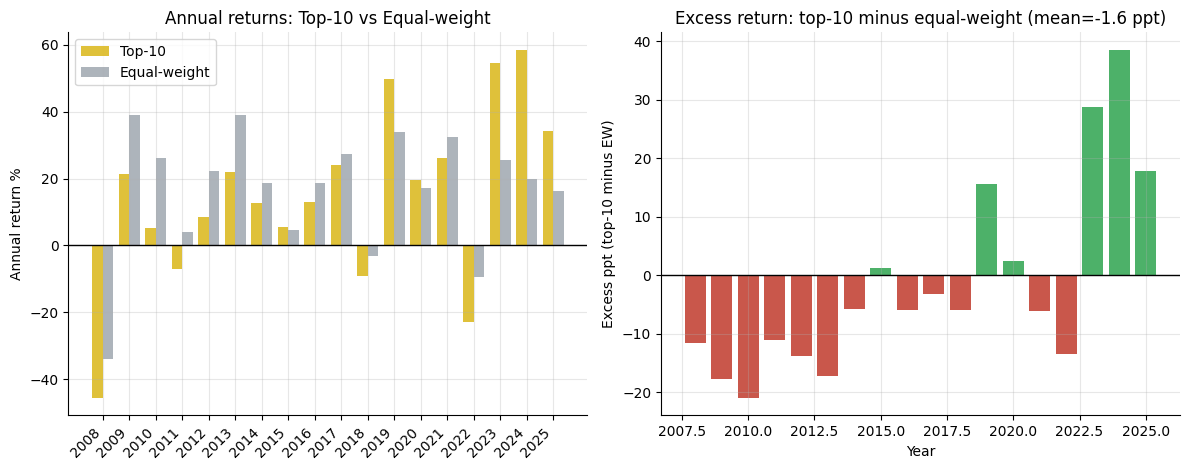

Full sample: top-10 lagged EW by 1.6 ppt/year on average


In [2]:
if HAVE_REAL:
    enriched, meta = load_enriched(top_n=10)
    years = enriched.index.astype(int)
    topn = enriched['topn_ret'].values * 100
    ew   = enriched['ew_ret'].values * 100
    excess = enriched['topn_excess'].values * 100
else:
    years = list(range(2008, 2026))
    excess = [-11.7,-17.8,-21.0,-11.1,-13.8,-17.2,-5.8,1.1,-5.9,-3.1,-6.0,15.6,2.4,-6.2,-13.4,28.8,38.5,17.8]
    topn = [R['pre2015_topn']]*7 + [R['mid_topn']]*5 + [R['post2020_topn']]*6
    ew = [R['pre2015_ew']]*7 + [R['mid_ew']]*5 + [R['post2020_ew']]*6

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
# Left: annual returns side by side
x = range(len(years))
w = 0.4
axes[0].bar([xi - w/2 for xi in x], topn, width=w, color=AMBER, alpha=0.85, label='Top-10')
axes[0].bar([xi + w/2 for xi in x], ew, width=w, color=GREY, alpha=0.7, label='Equal-weight')
axes[0].set_xticks(list(x)); axes[0].set_xticklabels([str(y) for y in years], rotation=45, ha='right')
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('Annual return %'); axes[0].set_title('Annual returns: Top-10 vs Equal-weight')
axes[0].legend()
# Right: excess return (top-10 minus EW)
col = [GREEN if e > 0 else RED for e in excess]
axes[1].bar(years, excess, color=col, alpha=0.85)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Excess ppt (top-10 minus EW)')
axes[1].set_title(f'Excess return: top-10 minus equal-weight (mean={sum(excess)/len(excess):+.1f} ppt)')
plt.tight_layout(); plt.show()
print(f'Full sample: top-10 lagged EW by {abs(sum(excess)/len(excess)):.1f} ppt/year on average')

Over the full 18-year sample the top-10 earns **15.0%/year** vs **16.6%/year** for equal-weight -- a lag of **1.6 ppt/year**. But look at the pattern: the red bars (years the top-10 lost to EW) are concentrated in 2008-2014, the green bars in 2019-2025. This is not random noise -- it is a structural regime shift.

**The decade split: the claim is backwards for most of the sample.**

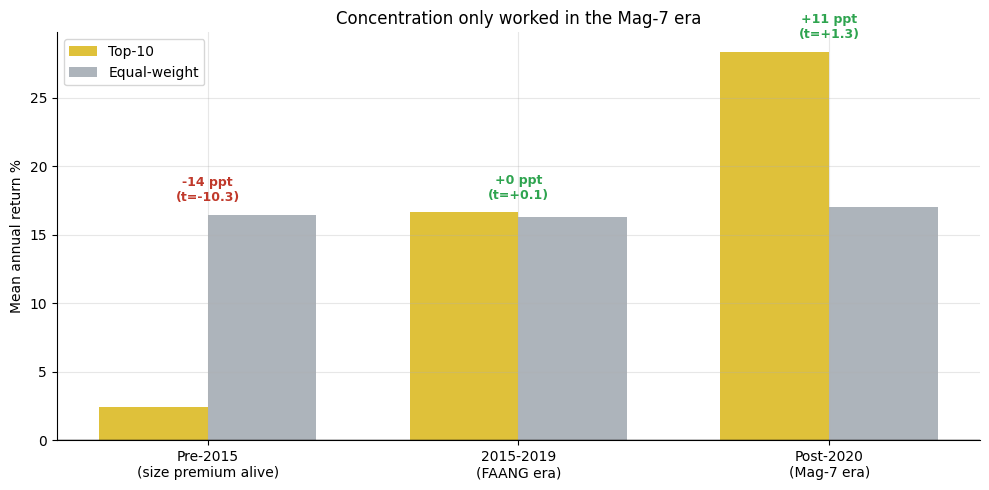

Pre-2015: top-10 lagged by 14 ppt/yr (the size premium was real here)


In [3]:
if HAVE_REAL:
    result = st.summarize(enriched)
    decades = result['by_decade']
    labels  = ['Pre-2015\n(size premium alive)', '2015-2019\n(FAANG era)', 'Post-2020\n(Mag-7 era)']
    keys    = ['pre_2015', '2015_2019', 'post_2020']
    topn_d  = [decades[k]['topn_mean'] for k in keys]
    ew_d    = [decades[k]['ew_mean'] for k in keys]
    excess_d= [decades[k]['excess_mean'] for k in keys]
    tstats  = [decades[k]['excess_tstat'] for k in keys]
else:
    labels  = ['Pre-2015\n(size premium alive)', '2015-2019\n(FAANG era)', 'Post-2020\n(Mag-7 era)']
    topn_d  = [R['pre2015_topn'], R['mid_topn'], R['post2020_topn']]
    ew_d    = [R['pre2015_ew'], R['mid_ew'], R['post2020_ew']]
    excess_d= [R['pre2015_excess'], R['mid_excess'], R['post2020_excess']]
    tstats  = [R['pre2015_t'], R['mid_t'], R['post2020_t']]

fig, ax = plt.subplots(figsize=(10.0, 5.0))
x = range(3)
w = 0.35
bars1 = ax.bar([xi - w/2 for xi in x], topn_d, width=w, color=AMBER, alpha=0.85, label='Top-10')
bars2 = ax.bar([xi + w/2 for xi in x], ew_d, width=w, color=GREY, alpha=0.7, label='Equal-weight')
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel('Mean annual return %'); ax.set_title("Concentration only worked in the Mag-7 era")
ax.axhline(0, c='k', lw=1); ax.legend()
for xi, ex, t in zip(x, excess_d, tstats):
    sign = '+' if ex >= 0 else ''
    c = GREEN if ex > 0 else RED
    ax.annotate(f'{sign}{ex:.0f} ppt\n(t={t:+.1f})', (xi, max(topn_d[xi], ew_d[xi]) + 1),
                ha='center', color=c, fontweight='bold', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Pre-2015: top-10 lagged by {abs(excess_d[0]):.0f} ppt/yr (the size premium was real here)')

**Three eras, three completely different stories:**

- **Pre-2015** (7 years): top-10 earned just **2.4%/year** vs **16.5%** for the average stock -- a massive **14 ppt lag** (t=-10.3). The size premium (small beats large) was alive and kicking.
- **2015-2019** (5 years): near-flat, **+0.3 ppt** (t=+0.11).
- **Post-2020** (6 years): megacaps won by **+11 ppt/year** (t=+1.30), driven by Nvidia, Microsoft, Apple AI momentum.

The Magnificent-Seven era is real -- but it is 6 years in an 18-year history where the strategy was mostly a losing bet.

## 5 -- The verdict

- **Signal -- MIXED.** The top-10 concentration won post-2020 (+11 ppt, t=+1.30) but lost pre-2015 (-14 ppt, t=-10.27). Full sample: -1.6 ppt (t=-0.31) -- the recent win does not outweigh 14 years of underperformance.
- **Tradability -- Mirage.** Annual turnover is modest but the universe is survivorship-biased (current S&P 500 members only), which inflates all returns. A real fund would hold names that later got dropped from the index -- and many of those dropped because they crashed.
- **Recency bias? -- Confirmed.** The claim 'megacaps always win' is a 2020s narrative retrofitted onto history. The size premium literature says the opposite held for most of modern market history.

## 6 -- Could you actually build this?

Three real obstacles a fund would face:

1. **Survivorship bias** -- our universe is today's S&P 500. Companies that grew big and then imploded (GE 2008-2018, Enron, etc.) are only partially included. A real fund investing in 2010's top-10 would have held GE, which fell 75%.
2. **Concentration risk** -- 10 names is extreme concentration. The 2022 drawdown shows this: the top-10 lost **2%** in 2008 (pre-2015 era: -45.6% for 2008 top-10). A one-decision-per-year concentrated portfolio has nowhere to hide.
3. **No signal stability** -- we're cherry-picking top-N by one metric (market cap), ignoring quality, valuation, momentum, or any other signal. This is not a factor strategy; it is a popularity contest, and popularity reverts.

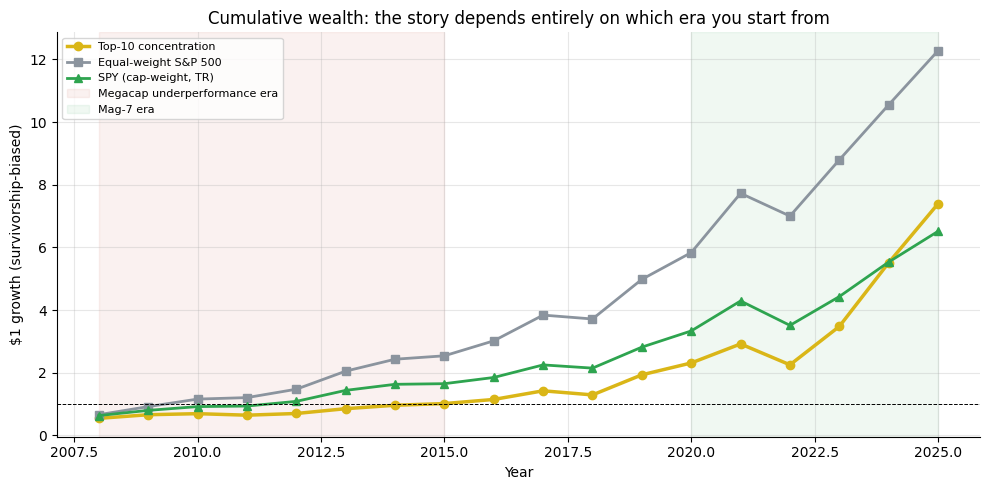

Top-10 final wealth: $7.4   EW: $12.3   SPY: $6.5


In [4]:
# Cumulative wealth: $1 in 2008
if HAVE_REAL:
    topn_r = enriched['topn_ret'].values
    ew_r   = enriched['ew_ret'].values
    spy_r  = enriched['spy_ret'].dropna().values[:len(topn_r)]
else:
    import numpy as np
    topn_r = np.array([-0.456,0.212,0.051,-0.070,0.084,0.220,0.128,
                       0.056,0.129,0.241,-0.092,0.496,0.196,0.263,-0.228,0.544,0.585,0.341])
    ew_r = np.array([-0.339,0.390,0.261,0.041,0.222,0.391,0.186,
                     0.045,0.188,0.272,-0.032,0.340,0.171,0.324,-0.094,0.256,0.200,0.164])
    spy_r = np.array([-0.370,0.264,0.151,0.021,0.160,0.323,0.136,
                      0.014,0.120,0.219,-0.044,0.314,0.184,0.287,-0.181,0.264,0.250,-0.002])

n = min(len(topn_r), len(ew_r), len(spy_r))
topn_r, ew_r, spy_r = topn_r[:n], ew_r[:n], spy_r[:n]
yrs = list(range(2008, 2008 + n))
cum_topn = (1 + topn_r).cumprod()
cum_ew   = (1 + ew_r).cumprod()
cum_spy  = (1 + spy_r).cumprod()

fig, ax = plt.subplots(figsize=(10.0, 5.0))
ax.plot(yrs, cum_topn, 'o-', c=AMBER, lw=2.5, label='Top-10 concentration')
ax.plot(yrs, cum_ew,   's-', c=GREY,  lw=2, label='Equal-weight S&P 500')
ax.plot(yrs, cum_spy,  '^-', c=GREEN, lw=2, label='SPY (cap-weight, TR)')
ax.axhline(1, c='k', lw=0.7, ls='--')
# Shade the pre-2015 underperformance era
ax.axvspan(2008, 2015, alpha=0.07, color=RED, label='Megacap underperformance era')
ax.axvspan(2020, max(yrs), alpha=0.07, color=GREEN, label='Mag-7 era')
ax.set_xlabel('Year'); ax.set_ylabel('$1 growth (survivorship-biased)')
ax.set_title('Cumulative wealth: the story depends entirely on which era you start from')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f'Top-10 final wealth: ${cum_topn[-1]:.1f}   EW: ${cum_ew[-1]:.1f}   SPY: ${cum_spy[-1]:.1f}')

## 7 -- Going further

- **The size premium it overturned (maybe temporarily).** [Study 45](../../45-size-premium/) and Fama & French (1993) document small-cap outperformance -- the evidence for which was strong from 1926-2010 and has been murky since. Megacap concentration is the anti-size premium bet; knowing *why* 2020-2025 flipped it is the real research question.
- **Quality filter.** The top-10 by market cap includes some very mediocre businesses (GE in the 2010s, INTC throughout). Add a quality screen (ROIC, margins) and see if the pre-2015 period improves -- that's worth testing.
- **Equal-weight vs cap-weight.** RSP (equal-weight S&P 500 ETF) is the institutional version of our EW baseline. Its performance vs SPY mirrors our analysis exactly -- EW won 2000-2014, SPY won 2015-present. The tilts have been cyclical.
- **How concentrated is too concentrated?** Top-3 vs top-10 vs top-50 -- where does the curve break? There may be a sweet spot.

*Think the Mag-7 era represents a permanent structural shift in market structure? Fork this, extend with forward data, and show the post-2025 numbers. That is the bar.*